In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

## load cleaned dataset
db = pd.read_csv('data/cmod_clean_200ms.csv')

In [20]:
db.columns

Index(['Unnamed: 0', 'shot', 'time', 'a_minor', 'beta_n', 'beta_p', 'bt',
       'chisq', 'dbetap_dt', 'dip_dt', 'dip_smoothed', 'dipprog_dt', 'dli_dt',
       'dn_dt', 'dprad_dt', 'dwmhd_dt', 'greenwald_fraction', 'i_efc', 'ip',
       'ip_error', 'ip_prog', 'kappa', 'kappa_area', 'li', 'lower_gap', 'n_e',
       'n_equal_1_mode', 'n_equal_1_normalized', 'n_equal_1_phase',
       'n_over_ncrit', 'ne_peaking', 'p_icrf', 'p_input', 'p_lh', 'p_oh',
       'p_rad', 'prad_peaking', 'pressure_peaking', 'q0', 'q95', 'qstar',
       'radiated_fraction', 'rmagx', 'ssep', 'sxr', 'tau_rad',
       'te_core_vs_avg_ece', 'te_edge_vs_avg_ece', 'te_peaking', 'te_width',
       'te_width_ece', 'time_until_disrupt', 'tribot', 'tritop', 'upper_gap',
       'v_loop', 'v_loop_efit', 'v_surf', 'v_z', 'wmhd', 'z_error', 'z_prog',
       'z_times_v_z', 'zcur', 'disruptive'],
      dtype='object')

feature_set options: ['density', 'generic', 'mhd', 'radiation', 'vde', 'targets']


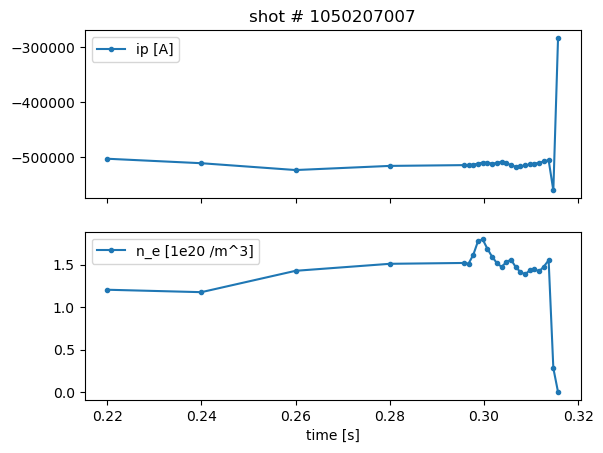

model inputs: ['a_minor', 'beta_n', 'beta_p', 'bt', 'chisq', 'greenwald_fraction', 'i_efc', 'ip', 'ip', 'ip_error', 'ip_error', 'ip_prog', 'kappa', 'kappa_area', 'li', 'li', 'lower_gap', 'n_e', 'n_e', 'n_equal_1_mode', 'n_equal_1_normalized', 'n_equal_1_phase', 'n_over_ncrit', 'ne_peaking', 'ne_peaking', 'p_icrf', 'p_icrf', 'p_input', 'p_input', 'p_lh', 'p_lh', 'p_oh', 'p_oh', 'p_rad', 'prad_peaking', 'pressure_peaking', 'q0', 'q95', 'qstar', 'radiated_fraction', 'rmagx', 'ssep', 'sxr', 'sxr', 'tau_rad', 'te_core_vs_avg_ece', 'te_core_vs_avg_ece', 'te_edge_vs_avg_ece', 'te_edge_vs_avg_ece', 'te_peaking', 'te_peaking', 'te_width', 'te_width', 'te_width_ece', 'te_width_ece', 'upper_gap', 'v_loop', 'v_loop', 'v_loop_efit', 'v_surf', 'v_z', 'wmhd', 'z_error', 'z_prog', 'z_times_v_z', 'zcur']


In [30]:
## load dict of relevant feature-sets
with open('data/raw_data/feature_sets_2025.json', 'r') as file:
    feature_sets = json.load(file)
print("feature_set options:", list(feature_sets.keys()))

## select a single feature/column
ip = db["ip"]

## create list of shots
db_shot_list = np.unique(db["shot"])

## plot feature traces for a given shot

# select a shot (shot_indx = 100)
temp_shot = db_shot_list[0]

# reduce database to only the selected shot
shot_data = db[db["shot"] == temp_shot]

# plot the plasma current ("ip") and plasma density ("n_e")
fig,ax = plt.subplots(2, 1, sharex=True)
ax[0].plot(shot_data["time"], shot_data["ip"], marker='.', label='ip [A]')
ax[1].plot(shot_data["time"], shot_data["n_e"] * 1e-20, marker='.', label='n_e [1e20 /m^3]')
for ii in ax:
    ii.legend()
ax[-1].set_xlabel("time [s]")
ax[0].set_title(f"shot # {temp_shot}")
plt.show()

## select all relevant features

# select relevant feature-set
# chose from:
#       ["generic", "mhd", "radiation", "vde", "density"]
feature_option = "vde"

# select only those columns
db_relevant = db[feature_sets[feature_option]]

## seperate inputs and targets for model(s)
## (and treat data-points as independent)

# select targets
# chose from two options:
#       ["time_until_disrupt", "disruptive"]
#         ^^regression          ^^classification
target_data = db["time_until_disrupt"]

# use all features within 'feature_sets' (other than 'targets')
# (leaving out 'shot' and 'time' columns treats data-points as independent)
included_features = []
for ff in feature_sets:
    if ff != "targets":
        included_features += feature_sets[ff]
included_features.sort()
input_data = db[included_features]

print("model inputs:", list(input_data.columns))